Passenger numbers of Suomenlinna ferry
https://www.avoindata.fi/data/en_GB/dataset/suomenlinnan-lautan-matkustajamaarat

Helsinki Region Transport's (HSL) LATI Web service is a ferry traffic statistics application commissioned by HSL. The system records the number of passengers, transported vehicles and passengers and/or vehicles that did not fit on the departure in question.

The ferries MS Suomenlinna II, MS Suokki and MS Tor operate from Kauppatori to Suomenlinna. The maximum transport capacity of MS Suokki and MS Tor is 350 persons and MS Suomenlinna II 395 persons.

The service ferry MS Ehrensvärd operates from Katajanokka to Suomenlinna. MS Ehrensvärd can also transport trucks and lorries and can take a maximum of 200 passengers.

More detailed description of the API: https://hsl.louhin.com/lati/help

In [5]:
import requests
import pandas as pd
import io

In [ ]:
## single page

# s = requests.Session()
# url = 'https://louhin.hsl.fi/api/1.0/data/257001'
# getentries = 10000

# offset = 0
# limit = 50
# headers = {'Authorization': 'LWS d59c041a-2ad1-4beb-b769-b9d7ea3a5628'}

# api_request = s.get(f"{url}?offset={offset}&limit={limit}", headers=headers)

# # print response code
# print(api_request)

# # print encoding of response
# print(api_request.encoding)

# print(api_request.text)


# with open('ferry_downloaded.csv', 'w', encoding='ISO-8859-1') as file:
#     file.write(api_request.text)

In [ ]:
session = requests.Session()
df = pd.DataFrame()
offset = 0

def get_batch(df, offset):
  url = "https://louhin.hsl.fi/api/1.0/data/257001"
  limit = 10000
  headers = {'Authorization': 'LWS d59c041a-2ad1-4beb-b769-b9d7ea3a5628'}
  api_request = session.get(f"{url}?offset={offset}&limit={limit}&filter[VUOSI]=2025", headers=headers) # filter by 2025
  newdf = pd.read_csv(io.StringIO(api_request.content.decode('ISO-8859-1')), delimiter=";", header=0, index_col=0)
  nextoffset = offset + limit

  if len(newdf) == limit:
    nextoffset = offset + limit
  else:
    nextoffset = None  # last page

  return pd.concat([df, newdf], axis=0), nextoffset

while offset is not None:
  df, offset = get_batch(df, offset)

df.head()


,ID,PÄIVÄMÄÄRÄ,VUOSI,NELJÄNNES,KUUKAUSI,VIIKKO,PÄIVÄ,KUUKAUSIPÄIVÄ,TUNTI,LOMA,...,SADE_PÄIVÄ,LÄMPÖTILA,SADE,TUULI,TAPAHTUMA,AJAMATON,LISÄTIETOJA,User,PYÖRÄT,RANNALLE_PYÖRÄT
label,,,,,,,,,,,,,,,,,,,,,
1,NaN,2025-01-01 06:00:00,2025,1,1,1,2,1,6,1,...,4.9,-2.3,0.8,4.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
2,NaN,2025-01-01 06:20:00,2025,1,1,1,2,1,6,1,...,4.9,-2.5,1.0,5.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
3,NaN,2025-01-01 06:40:00,2025,1,1,1,2,1,6,1,...,4.9,-2.4,1.3,6.9,NaN,False,NaN,MS Suomenlinna II,0,NaN
4,NaN,2025-01-01 07:00:00,2025,1,1,1,2,1,7,1,...,4.9,-2.3,1.4,7.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
5,NaN,2025-01-01 07:20:00,2025,1,1,1,2,1,7,1,...,4.9,-1.9,0.7,7.9,NaN,False,NaN,MS Suomenlinna II,0,NaN


Let's translate this

In [15]:
df = df.rename(columns={'PÄIVÄMÄÄRÄ': 'Date',
                        'VUOSI': 'Year',
                        "NELJÄNNES": 'Quarter',
                        'KUUKAUSI': 'Month',
                        'VIIKKO': 'Week',
                        'PÄIVÄ': 'Day',
                        'KUUKAUSIPÄIVÄ': 'Monthday',
                        'TUNTI': 'Hour',
                        'LOMA': 'Holiday',
                        'Vapaapäivä': 'Day off',
                        'ALUS':'Ship',
                        'SUUNTA': 'Direction',
                        'PYSÄKKI': 'Stop',
                        'NOUSIJAT': 'Passengers',
                        'AJONEUVOT': 'Vehicles',
                        'HENKILÖAUTOT': 'Passenger cars',
                        'PAKETTIAUTOT': 'Cargo vehicles',
                        'KUORMA-AUTOT': 'Heavy-duty vehicles',
                        'REKAT': 'Vessels',
                        'MUUT': 'Others',
                        'LISÄLIIKENNE': 'Additional traffic',
                        'RANNALLE_NOUSIJAT': 'Passengers (left on shore)',
                        'RANNALLE_AJONEUVOT': 'Vehicles (left on shore)',
                        'RANNALLE_HENKILÖAUTOT': 'Passenger cars (left on shore)',
                        'RANNALLE_PAKETTIAUTOT': 'Cargo vehicles (left on shore)',
                        'RANNALLE_KUORMA-AUTOT': 'Heavy-duty vehicles (left on shore)',
                        'RANNALLE_REKAT': 'Vessels (left on shore)',
                        'RANNALLE_MUUT': 'Others (left on shore)',
                        'LÄMPÖTILA_KUUKAUSI': 'Temperature (monthly average)',
                        'SADE_KUUKAUSI': 'Precipitation (monthly total)',
                        'LÄMPÖTILA_PÄIVÄ': 'Temperature (daily average)',
                        'SADE_PÄIVÄ': 'Precipitation (daily total)',
                        'LÄMPÖTILA': 'Temperature',
                        'SADE': 'Precipitation',
                        'TUULI': 'Wind',
                        'TAPAHTUMA': 'Event',
                        'AJAMATON': 'Delayed departure',
                        'LISÄTIETOJA': 'Additional information',
                        'User': 'User',
                        'PYÖRÄT': 'Bicycles',
                        'RANNALLE_PYÖRÄT': 'Bicycles (left on shore)'
                        })
df.head(5)

,ID,Date,Year,Quarter,Month,Week,Day,Monthday,Hour,Holiday,...,Precipitation (daily total),Temperature,Precipitation,Wind,Event,Delayed departure,Additional information,User,Bicycles,Bicycles (left on shore)
label,,,,,,,,,,,,,,,,,,,,,
1,NaN,2025-01-01 06:00:00,2025,1,1,1,2,1,6,1,...,4.9,-2.3,0.8,4.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
2,NaN,2025-01-01 06:20:00,2025,1,1,1,2,1,6,1,...,4.9,-2.5,1.0,5.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
3,NaN,2025-01-01 06:40:00,2025,1,1,1,2,1,6,1,...,4.9,-2.4,1.3,6.9,NaN,False,NaN,MS Suomenlinna II,0,NaN
4,NaN,2025-01-01 07:00:00,2025,1,1,1,2,1,7,1,...,4.9,-2.3,1.4,7.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
5,NaN,2025-01-01 07:20:00,2025,1,1,1,2,1,7,1,...,4.9,-1.9,0.7,7.9,NaN,False,NaN,MS Suomenlinna II,0,NaN


Save to file

In [16]:
df.to_csv('ferry_downloaded.csv', encoding='ISO-8859-1', index=True, sep=';')

Read from file instead

In [6]:
df = pd.read_csv('ferry_downloaded.csv', index_col=0, delimiter=';', encoding='ISO-8859-1')
df.head()

,ID,Date,Year,Quarter,Month,Week,Day,Monthday,Hour,Holiday,...,Precipitation (daily total),Temperature,Precipitation,Wind,Event,Delayed departure,Additional information,User,Bicycles,Bicycles (left on shore)
label,,,,,,,,,,,,,,,,,,,,,
1,NaN,2025-01-01 06:00:00,2025,1,1,1,2,1,6,1,...,4.9,-2.3,0.8,4.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
2,NaN,2025-01-01 06:20:00,2025,1,1,1,2,1,6,1,...,4.9,-2.5,1.0,5.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
3,NaN,2025-01-01 06:40:00,2025,1,1,1,2,1,6,1,...,4.9,-2.4,1.3,6.9,NaN,False,NaN,MS Suomenlinna II,0,NaN
4,NaN,2025-01-01 07:00:00,2025,1,1,1,2,1,7,1,...,4.9,-2.3,1.4,7.7,NaN,False,NaN,MS Suomenlinna II,0,NaN
5,NaN,2025-01-01 07:20:00,2025,1,1,1,2,1,7,1,...,4.9,-1.9,0.7,7.9,NaN,False,NaN,MS Suomenlinna II,0,NaN


In [7]:
# Return the memory usage of each column in bytes.
df.memory_usage()

Index                                  138544
ID                                     138544
Date                                   138544
Year                                   138544
Quarter                                138544
Month                                  138544
Week                                   138544
Day                                    138544
Monthday                               138544
Hour                                   138544
Holiday                                138544
Ship                                   138544
Direction                              138544
Stop                                   138544
Passengers                             138544
Vehicles                               138544
Passenger cars                         138544
Cargo vehicles                         138544
Heavy-duty vehicles                    138544
Vessels                                138544
Others                                 138544
Additional traffic                

In [8]:
df.describe(include = "all")

,ID,Date,Year,Quarter,Month,Week,Day,Monthday,Hour,Holiday,...,Precipitation (daily total),Temperature,Precipitation,Wind,Event,Delayed departure,Additional information,User,Bicycles,Bicycles (left on shore)
count,0.0,17318,17318.0,17318.000000,17318.000000,17318.000000,17318.000000,17318.000000,17318.000000,17318.000000,...,17115.000000,17318.000000,17316.000000,17081.000000,0.0,17318,113,17318,17318.000000,0.0
unique,NaN,14587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2,31,6,NaN,NaN
top,NaN,2025-05-07 10:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,mp,MS Suomenlinna II,NaN,NaN
freq,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,17279,32,5583,NaN,NaN
mean,NaN,NaN,2025.0,1.506352,3.353794,13.020614,2.866497,15.373715,13.096605,0.286638,...,0.430757,5.211422,0.045467,4.086775,NaN,NaN,NaN,NaN,0.961774,NaN
std,NaN,NaN,0.0,0.499974,1.520800,6.521324,1.958089,8.963637,5.522424,0.452204,...,2.741888,6.103234,0.306478,1.733583,NaN,NaN,NaN,NaN,1.584718,NaN
min,NaN,NaN,2025.0,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,-1.000000,-14.100000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,2025.0,1.000000,2.000000,7.000000,1.000000,7.000000,9.000000,0.000000,...,-1.000000,1.200000,0.000000,2.900000,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,2025.0,2.000000,4.000000,14.000000,3.000000,15.000000,13.000000,0.000000,...,-1.000000,4.700000,0.000000,3.900000,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,2025.0,2.000000,5.000000,19.000000,4.000000,23.000000,17.000000,1.000000,...,0.700000,9.700000,0.000000,5.100000,NaN,NaN,NaN,NaN,1.000000,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17318 entries, 1 to 7318
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   0 non-null      float64
 1   Date                                 17318 non-null  object 
 2   Year                                 17318 non-null  int64  
 3   Quarter                              17318 non-null  int64  
 4   Month                                17318 non-null  int64  
 5   Week                                 17318 non-null  int64  
 6   Day                                  17318 non-null  int64  
 7   Monthday                             17318 non-null  int64  
 8   Hour                                 17318 non-null  int64  
 9   Holiday                              17318 non-null  int64  
 10  Ship                                 17318 non-null  object 
 11  Direction                         

<h4>Evaluating for Missing Data</h4>

The missing values are converted to default. We use the following functions to identify these missing values. There are two methods to detect missing data:

<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>
The output is a boolean value indicating whether the value that is passed into the argument is in fact missing data.
"True" stands for missing value, while "False" stands for not missing value.

In [10]:
missing_data = df.isnull()
missing_data.head(5)

,ID,Date,Year,Quarter,Month,Week,Day,Monthday,Hour,Holiday,...,Precipitation (daily total),Temperature,Precipitation,Wind,Event,Delayed departure,Additional information,User,Bicycles,Bicycles (left on shore)
label,,,,,,,,,,,,,,,,,,,,,
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
5,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True


In [11]:
df.isnull().sum()  

ID                                     17318
Date                                       0
Year                                       0
Quarter                                    0
Month                                      0
Week                                       0
Day                                        0
Monthday                                   0
Hour                                       0
Holiday                                    0
Ship                                       0
Direction                                  0
Stop                                       0
Passengers                                 0
Vehicles                                   0
Passenger cars                             0
Cargo vehicles                             0
Heavy-duty vehicles                        0
Vessels                                    0
Others                                     0
Additional traffic                         0
Passengers (left on shore)             17289
Vehicles (

In [12]:
# drop completely empty columns
df = df.drop(['ID', 'Bicycles (left on shore)'], axis=1)


Let's check that columns have correct types

In [13]:
df.dtypes

Date                                    object
Year                                     int64
Quarter                                  int64
Month                                    int64
Week                                     int64
Day                                      int64
Monthday                                 int64
Hour                                     int64
Holiday                                  int64
Ship                                    object
Direction                               object
Stop                                     int64
Passengers                               int64
Vehicles                                 int64
Passenger cars                           int64
Cargo vehicles                           int64
Heavy-duty vehicles                      int64
Vessels                                  int64
Others                                   int64
Additional traffic                       int64
Passengers (left on shore)             float64
Vehicles (lef

<p>As we can see above, some columns are not of the correct data type. Numerical variables should have type 'float' or 'int', and variables with strings such as categories should have type 'object'. For example, 'bore' and 'stroke' variables are numerical values that describe the engines, so we should expect them to be of the type 'float' or 'int'; however, they are shown as type 'object'. We have to convert data types into a proper format for each column using the "astype()" method.</p> 

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
df['Passengers (left on shore)'] = df['Passengers (left on shore)'].notnull().astype("int64")
df.dtypes

Date                                   datetime64[ns]
Year                                            int64
Quarter                                         int64
Month                                           int64
Week                                            int64
Day                                             int64
Monthday                                        int64
Hour                                            int64
Holiday                                         int64
Ship                                           object
Direction                                      object
Stop                                            int64
Passengers                                      int64
Vehicles                                        int64
Passenger cars                                  int64
Cargo vehicles                                  int64
Heavy-duty vehicles                             int64
Vessels                                         int64
Others                      

In [15]:
df['Passengers'].corr(df['Vehicles'])

0.17028349573992668

In [16]:
df['Passengers'].corr(df['Bicycles'])

0.17795456558977946

In [17]:
df['Passengers'].corr(df['Temperature (daily average)'])

0.15162162968370696

Amount of passengers does not seem to depend on temperature or be proprtional to the number of cars or bikes they bring

In [18]:
import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

fig = px.histogram(df, x= 'Passengers', title='Passengers', marginal="box", hover_data = df[['Date']])
fig.show()

In [19]:
fig = px.bar(x= df['Ship'].value_counts().index, y=df.groupby('Ship')['Passengers'].sum(), 
             title='Passengers by each ship', labels={'y':'Passengers', 'x':'Ship'})
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [20]:
fig = px.scatter(df, x="Hour", y="Passengers", hover_data="Date")
fig.show()

In [21]:
df['Precipitation'].describe()

count    17316.000000
mean         0.045467
std          0.306478
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          9.800000
Name: Precipitation, dtype: float64

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

(0.0, 22.05)

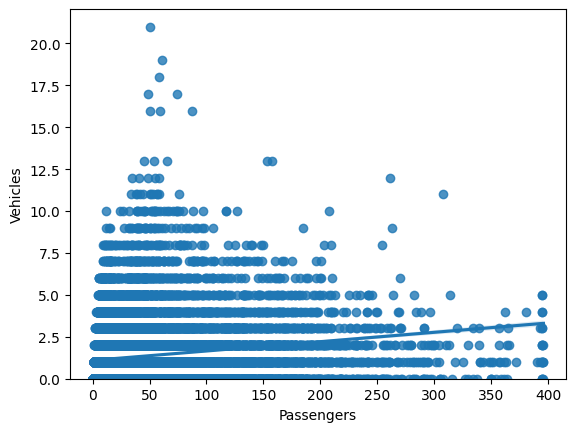

In [23]:
sns.regplot(x="Passengers", y="Vehicles", data=df)
plt.ylim(0,)

<Axes: xlabel='Ship', ylabel='Passengers'>

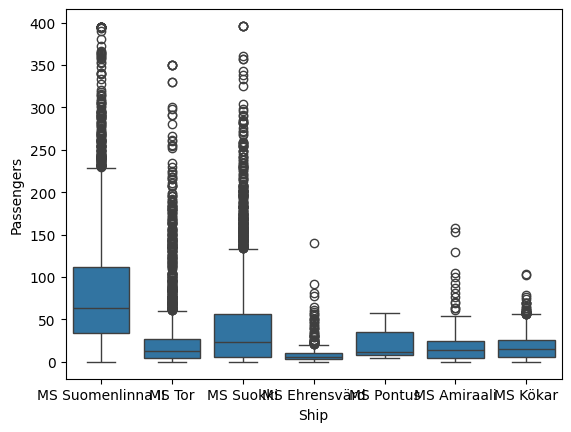

In [24]:
sns.boxplot(x="Ship", y="Passengers", data=df)